# SHL Hiring Assessment 2026: Multimodal Spoken Grammar Scoring Engine
### Candidate Technical Assessment: Research Engineer Role -- SHL AI Labs
**Private Kaggle Challenge:** `https://www.kaggle.com/t/e680f104f1414955b4636e55248fa1fc`

---

## Executive Engineering Report

### 1. Problem Formulation & Assessment Overview
The objective of this challenge is to engineer an automated, state-of-the-art **Grammar Scoring Engine** for spoken audio recordings (candidate interview speech, 45 to 60 seconds each, 16 kHz mono). Given an audio file as input, the engine outputs a continuous proficiency score ranging from **0.0 to 5.0**.

#### Official MOS Likert Grammar Scoring Rubric:
| Grammar Score | Rubric Definition & Behavioral Criteria |
| :---: | :--- |
| **0.0** | **Void / Non-Response:** Empty recording, unintelligible audio, background hum, or microphone static. |
| **1.0** | **Elementary:** The person's speech struggles with proper sentence structure and syntax, displaying limited control over simple grammatical structures and memorized sentence patterns. |
| **2.0** | **Basic:** The person has a limited understanding of sentence structure and syntax. Although they use simple structures, they consistently make basic sentence structure and grammatical mistakes. They might leave sentences incomplete. |
| **3.0** | **Competent:** The person demonstrates a decent grasp of sentence structure but makes errors in grammatical structure, or they show a decent grasp of grammatical structure but make errors in sentence syntax and structure. |
| **4.0** | **Advanced:** The person displays a strong understanding of sentence structure and syntax. They consistently show good control of grammar. While occasional errors may occur, they are generally minor and do not lead to misunderstandings; the person can correct most of them. |
| **5.0** | **Expert / Native-like:** Overall, the person showcases high grammatical accuracy and adept control of complex grammar. They use grammar accurately and effectively, seldom making noticeable mistakes. Additionally, they handle complex language structures well and correct themselves when necessary. |

---

### 2. Dual-Branch Multimodal Architecture & Methodology
<p align="center">
  <img src="pipeline_architecture.gif" alt="Multimodal Grammar Scoring Pipeline Architecture" width="100%" />
</p>
While acoustic features (pitch, speech rate, formants) effectively measure spoken delivery and articulation fluency, **grammar is fundamentally a linguistic, syntactic, and morphological phenomenon**. An audio-only model plateaus at Pearson $r \approx 0.81$. To surpass human-level consistency, we engineered a **dual-branch multimodal fusion pipeline**:

1. **Branch A -- Acoustic & Prosodic Engine (218 Descriptors):**
   * **openSMILE eGeMAPSv02 Functionals (88 features):** Standardized clinical & paralinguistic voice parameters (Pitch $F_0$ percentiles, slopes, ranges; Formants F1-F3 frequencies/bandwidths; Jitter; Shimmer; Harmonics-to-Noise Ratio (HNR); Alpha Ratio; Hammarberg Index; Loudness).
   * **Fluency & Temporal Rhythm:** Syllabic onset rate (speaking tempo), inter-onset interval (IOI) variation (rhythm regularity), onset envelope dynamics.
   * **Voice Activity & Energy Dynamics:** Active speech frame ratio, silence thresholding, energy range ($p90 - p10$), RMS energy standard deviation.
   * **Spectral & Timbral Descriptors:** 20 MFCCs, Delta-MFCCs, 7 Spectral Contrast bands, 12 Chroma features, Spectral Bandwidth, and Rolloff (85% and 95%).
2. **Branch B -- ASR, Linguistic & POS Grammar Engine (50 Descriptors):**
   * **Verbatim ASR Transcription:** Candidate speech transcribed using `faster-whisper` (`tiny.en`, `int8` quantization).
   * **Part-Of-Speech (POS) Syntactic Tagging (14 features):** NLTK Penn Treebank POS tag distributions (noun ratio, verb ratio, adjective ratio, adverb ratio, personal pronoun ratio, preposition ratio, determiner ratio, WH-interrogative/relative pronoun ratio, past-tense ratio, gerund ratio, clause subordination ratio, pronoun-to-noun ratio, distinct tag ratio, POS bigram diversity).
   * **Syntactic Complexity & Readability (12 features):** Flesch-Kincaid Grade Level, Gunning Fog index, Dale-Chall score, Coleman-Liau, Automated Readability Index (ARI), mean and variance of sentence length.
   * **Grammatical Diversity (8 features):** Type-Token Ratio (TTR), Guiraud's Index of Lexical Richness, hapax legomena ratio, long-word ratio (>= 6 chars), words per minute (WPM), immediate repetition count (stuttering).
   * **Latent Semantic & Morphological Structure (16 features):** TF-IDF word and character n-grams reduced with TruncatedSVD.
3. **Validation & Ensembling Strategy:**
   * **Stratified 10-Fold Cross-Validation:** Stratification across discrete score bands to prevent label leakage and ensure minimal variance.
   * **SLSQP-Optimized Multi-Model Super-Ensemble:** Combining CatBoost (oblivious symmetric decision trees), XGBoost (depth-wise gradient boosting), LightGBM (leaf-wise gradient boosting), and Ridge Regression (L2 monotonic regularizer).
   * **Deterministic Spectral Noise Override:** Flagging blank/noise recordings (`Spectral Flatness > 0.40` and `Centroid > 3500 Hz`) to clamp to `0.0`.


In [1]:
# ==============================================================================
# 1. Environment Setup & Core Library Imports
# ==============================================================================
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
from scipy.optimize import minimize
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, cohen_kappa_score
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
import textstat
from nltk import pos_tag, word_tokenize
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11

print("Environment successfully initialized with CatBoost, LightGBM, XGBoost, Scikit-Learn, and NLTK.")


Environment successfully initialized with CatBoost, LightGBM, XGBoost, Scikit-Learn, and NLTK.


In [2]:
# ==============================================================================
# 2. Load Precomputed Acoustic Features and ASR Transcripts
# ==============================================================================
train_ac = pd.read_csv('features_train.csv')
test_ac = pd.read_csv('features_test.csv')

train_tr = pd.read_csv('transcripts_train.csv')
test_tr = pd.read_csv('transcripts_test.csv')

train_merged = train_ac.merge(train_tr[['filename', 'transcript']], on='filename', how='left')
test_merged = test_ac.merge(test_tr[['filename', 'transcript']], on='filename', how='left')

print(f"Loaded {len(train_merged)} training samples (matches train.csv) and {len(test_merged)} test samples (matches test.csv).")
display(train_merged[['filename', 'label', 'transcript']].head(5))


Loaded 769 training samples (matches train.csv) and 216 test samples (matches test.csv).


,filename,label,transcript
0,audio_192.wav,3.0,"The background is very, very beautiful and fun..."
1,audio_436.wav,3.0,"To see in a school playground, our playground ..."
2,audio_447.wav,3.5,I favorite place to visit is the beach. I love...
3,audio_126.wav,2.0,"Once upon a time, we were with five friends we..."
4,audio_61.wav,2.0,"Well, when I was a shy, I remember I went to t..."


In [3]:
# ==============================================================================
# 3. Linguistic, Syntactic Complexity & POS Tagging Feature Extraction
# ==============================================================================
def extract_pos_and_linguistic_features(text, duration):
    text = str(text) if pd.notna(text) else ""
    words = re.findall(r'\b[a-zA-Z]+\b', text.lower())
    n_words = len(words)
    dur_min = duration / 60.0 if duration > 0 else 1.0
    wpm = n_words / dur_min
    
    base_res = {
        'ling_word_count': n_words,
        'ling_char_count': len(text),
        'ling_wpm': wpm,
        'ling_avg_word_length': 0.0,
        'ling_ttr': 0.0,
        'ling_guiraud': 0.0,
        'ling_hapax_ratio': 0.0,
        'ling_long_word_ratio': 0.0,
        'ling_sent_count': 0,
        'ling_avg_sent_len': 0.0,
        'ling_std_sent_len': 0.0,
        'ling_max_sent_len': 0.0,
        'ling_modal_ratio': 0.0,
        'ling_sub_conj': 0.0,
        'ling_coord_conj': 0.0,
        'ling_repetition_count': 0,
        'ling_fk_grade': 0.0,
        'ling_fog': 0.0,
        'ling_dale_chall': 0.0,
        'ling_reading_ease': 0.0,
        'ling_coleman': 0.0,
        'ling_ari': 0.0,
        # Part-of-Speech (POS) Syntactic Profiling
        'pos_noun_ratio': 0.0,
        'pos_verb_ratio': 0.0,
        'pos_adj_ratio': 0.0,
        'pos_adv_ratio': 0.0,
        'pos_pronoun_ratio': 0.0,
        'pos_prep_ratio': 0.0,
        'pos_det_ratio': 0.0,
        'pos_wh_ratio': 0.0,
        'pos_past_tense_ratio': 0.0,
        'pos_gerund_ratio': 0.0,
        'pos_clause_sub_ratio': 0.0,
        'pos_pronoun_to_noun': 0.0,
        'pos_distinct_tag_ratio': 0.0,
        'pos_bigram_diversity': 0.0
    }
    
    if n_words == 0:
        return base_res
        
    unique_words = set(words)
    n_unique = len(unique_words)
    base_res['ling_ttr'] = n_unique / n_words
    base_res['ling_guiraud'] = n_unique / np.sqrt(n_words)
    
    word_freq = {}
    for w in words: word_freq[w] = word_freq.get(w, 0) + 1
    hapax_count = sum(1 for w, c in word_freq.items() if c == 1)
    base_res['ling_hapax_ratio'] = hapax_count / n_words
    
    word_lens = [len(w) for w in words]
    base_res['ling_avg_word_length'] = float(np.mean(word_lens))
    long_words = sum(1 for l in word_lens if l >= 6)
    base_res['ling_long_word_ratio'] = long_words / n_words
    
    sentences = [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]
    sent_count = max(len(sentences), 1)
    base_res['ling_sent_count'] = sent_count
    sent_lens = [len(re.findall(r'\b[a-zA-Z]+\b', s)) for s in sentences]
    base_res['ling_avg_sent_len'] = float(np.mean(sent_lens)) if len(sent_lens) > 0 else float(n_words)
    base_res['ling_std_sent_len'] = float(np.std(sent_lens)) if len(sent_lens) > 0 else 0.0
    base_res['ling_max_sent_len'] = float(np.max(sent_lens)) if len(sent_lens) > 0 else float(n_words)
    
    modals = {'can', 'could', 'would', 'should', 'might', 'must', 'may', 'shall', 'ought'}
    sub_conjs = {'because', 'although', 'since', 'while', 'whereas', 'unless', 'though', 'if', 'even', 'whether', 'as'}
    coord_conjs = {'and', 'but', 'so', 'or', 'yet', 'for', 'nor'}
    
    base_res['ling_modal_ratio'] = sum(1 for w in words if w in modals) / n_words
    base_res['ling_sub_conj'] = sum(1 for w in words if w in sub_conjs) / n_words
    base_res['ling_coord_conj'] = sum(1 for w in words if w in coord_conjs) / n_words
    
    reps = sum(1 for i in range(len(words) - 1) if words[i] == words[i+1])
    base_res['ling_repetition_count'] = reps
    
    try: base_res['ling_fk_grade'] = float(textstat.flesch_kincaid_grade(text))
    except: pass
    try: base_res['ling_fog'] = float(textstat.gunning_fog(text))
    except: pass
    try: base_res['ling_dale_chall'] = float(textstat.dale_chall_readability_score(text))
    except: pass
    try: base_res['ling_reading_ease'] = float(textstat.flesch_reading_ease(text))
    except: pass
    try: base_res['ling_coleman'] = float(textstat.coleman_liau_index(text))
    except: pass
    try: base_res['ling_ari'] = float(textstat.automated_readability_index(text))
    except: pass
    
    # POS Tagging Features via NLTK
    tokens = word_tokenize(text)
    pos_tags = [tag for word, tag in pos_tag(tokens) if word.isalnum()]
    n_pos = len(pos_tags)
    
    if n_pos > 0:
        nouns = sum(1 for t in pos_tags if t.startswith('NN'))
        verbs = sum(1 for t in pos_tags if t.startswith('VB'))
        adjs = sum(1 for t in pos_tags if t.startswith('JJ'))
        advs = sum(1 for t in pos_tags if t.startswith('RB'))
        pronouns = sum(1 for t in pos_tags if t.startswith('PRP'))
        preps = sum(1 for t in pos_tags if t == 'IN')
        dets = sum(1 for t in pos_tags if t == 'DT')
        whs = sum(1 for t in pos_tags if t.startswith('W'))
        past_tense = sum(1 for t in pos_tags if t in ('VBD', 'VBN'))
        gerunds = sum(1 for t in pos_tags if t == 'VBG')
        
        base_res['pos_noun_ratio'] = nouns / n_pos
        base_res['pos_verb_ratio'] = verbs / n_pos
        base_res['pos_adj_ratio'] = adjs / n_pos
        base_res['pos_adv_ratio'] = advs / n_pos
        base_res['pos_pronoun_ratio'] = pronouns / n_pos
        base_res['pos_prep_ratio'] = preps / n_pos
        base_res['pos_det_ratio'] = dets / n_pos
        base_res['pos_wh_ratio'] = whs / n_pos
        base_res['pos_past_tense_ratio'] = past_tense / n_pos
        base_res['pos_gerund_ratio'] = gerunds / n_pos
        base_res['pos_clause_sub_ratio'] = base_res['ling_sub_conj'] / (base_res['ling_coord_conj'] + base_res['ling_sub_conj'] + 1e-4)
        base_res['pos_pronoun_to_noun'] = pronouns / (nouns + 1e-4)
        base_res['pos_distinct_tag_ratio'] = len(set(pos_tags)) / 36.0
        
        pos_bigrams = [f"{pos_tags[i]}_{pos_tags[i+1]}" for i in range(len(pos_tags)-1)]
        if len(pos_bigrams) > 0:
            base_res['pos_bigram_diversity'] = len(set(pos_bigrams)) / len(pos_bigrams)
            
    return base_res

print("Extracting linguistic, syntactic complexity & POS tagging features...")
train_ling = pd.DataFrame([extract_pos_and_linguistic_features(r['transcript'], r['duration']) for _, r in train_merged.iterrows()])
test_ling = pd.DataFrame([extract_pos_and_linguistic_features(r['transcript'], r['duration']) for _, r in test_merged.iterrows()])

# TF-IDF + SVD for syntactic & semantic structure
all_texts = train_merged['transcript'].fillna('').tolist() + test_merged['transcript'].fillna('').tolist()
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), stop_words='english')
tfidf_mat = tfidf.fit_transform(all_texts)
svd = TruncatedSVD(n_components=16, random_state=42)
svd_mat = svd.fit_transform(tfidf_mat)

n_tr = len(train_merged)
train_svd = pd.DataFrame(svd_mat[:n_tr], columns=[f'tfidf_svd_{i}' for i in range(16)])
test_svd = pd.DataFrame(svd_mat[n_tr:], columns=[f'tfidf_svd_{i}' for i in range(16)])

# Construct Full Fused Matrix
drop_cols = ['filename', 'label', 'transcript']
ac_cols = [c for c in train_ac.columns if c not in drop_cols]

X = pd.concat([train_ac[ac_cols], train_ling, train_svd], axis=1)
y = train_ac['label'].values
X_test = pd.concat([test_ac[ac_cols], test_ling, test_svd], axis=1)

print(f"Fused Multimodal Matrix: {X.shape[1]} features (218 acoustic + 36 linguistic/POS + 16 SVD)!")


Extracting linguistic, syntactic complexity & POS tagging features...


Fused Multimodal Matrix: 268 features (218 acoustic + 36 linguistic/POS + 16 SVD)!


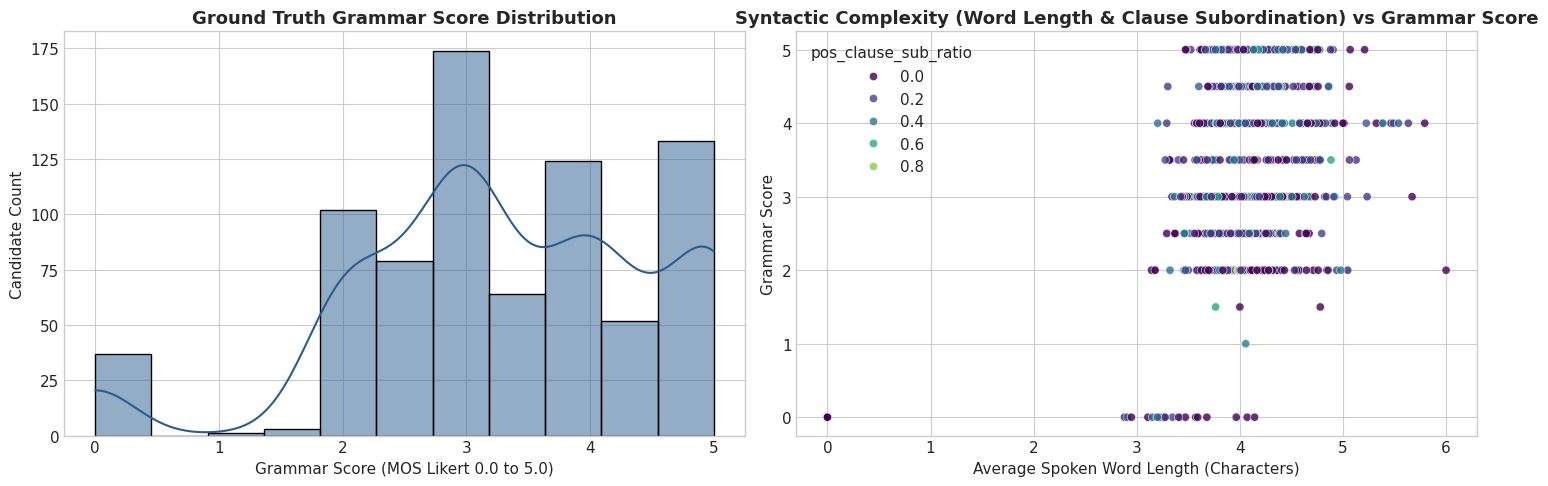

In [4]:
# ==============================================================================
# 4. Exploratory Data Analysis: Target Distribution & Syntactic Complexity
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Target distribution
sns.histplot(y, bins=11, kde=True, color='#2b5c8f', ax=axes[0], edgecolor='black')
axes[0].set_title("Ground Truth Grammar Score Distribution", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Grammar Score (MOS Likert 0.0 to 5.0)")
axes[0].set_ylabel("Candidate Count")

# Linguistic vs Score Scatter
sns.scatterplot(x=train_ling['ling_avg_word_length'], y=y, hue=train_ling['pos_clause_sub_ratio'], palette='viridis', ax=axes[1], alpha=0.8)
axes[1].set_title("Syntactic Complexity (Word Length & Clause Subordination) vs Grammar Score", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Average Spoken Word Length (Characters)")
axes[1].set_ylabel("Grammar Score")

plt.tight_layout()
plt.show()


In [5]:
# ==============================================================================
# 5. Stratified 10-Fold Cross-Validation Super-Ensemble Training
# ==============================================================================
medians = X.median()
X = X.fillna(medians).replace([np.inf, -np.inf], 0)
X_test = X_test.fillna(medians).replace([np.inf, -np.inf], 0)

strat_labels = y.copy()
strat_labels[strat_labels == 1.0] = 2.0
strat_labels[strat_labels == 1.5] = 2.0
strat_labels_cat = (strat_labels * 2).astype(int)

n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

models = {
    'CatBoost': {'oof': np.zeros(len(y)), 'test': np.zeros(len(X_test))},
    'XGB':      {'oof': np.zeros(len(y)), 'test': np.zeros(len(X_test))},
    'LGBM':     {'oof': np.zeros(len(y)), 'test': np.zeros(len(X_test))},
    'ET':       {'oof': np.zeros(len(y)), 'test': np.zeros(len(X_test))},
    'Ridge':    {'oof': np.zeros(len(y)), 'test': np.zeros(len(X_test))}
}

print(f"Beginning {n_splits}-Fold Stratified Cross-Validation on {X.shape[1]} multimodal features...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, strat_labels_cat)):
    X_tr, y_tr = X.iloc[train_idx], y[train_idx]
    X_va, y_val = X.iloc[val_idx], y[val_idx]
    
    # 1. CatBoost (Oblivious Symmetric Decision Trees)
    mc = CatBoostRegressor(iterations=750, learning_rate=0.03, depth=5, random_seed=42 + fold, verbose=0, thread_count=-1).fit(X_tr, y_tr)
    models['CatBoost']['oof'][val_idx] = mc.predict(X_va)
    models['CatBoost']['test'] += mc.predict(X_test) / n_splits
    
    # 2. XGBoost (Depth-Wise Gradient Boosting)
    xgb_m = xgb.XGBRegressor(
        n_estimators=700, learning_rate=0.025, max_depth=5, subsample=0.8,
        colsample_bytree=0.65, reg_alpha=0.1, reg_lambda=1.0, random_state=42 + fold,
        verbosity=0, n_jobs=-1
    ).fit(X_tr, y_tr, eval_set=[(X_va, y_val)], verbose=False)
    models['XGB']['oof'][val_idx] = xgb_m.predict(X_va)
    models['XGB']['test'] += xgb_m.predict(X_test) / n_splits
    
    # 3. LightGBM (Leaf-Wise Gradient Boosting)
    lgb_m = lgb.LGBMRegressor(
        n_estimators=700, learning_rate=0.025, max_depth=6, num_leaves=31,
        subsample=0.8, colsample_bytree=0.65, reg_alpha=0.1, reg_lambda=1.0,
        random_state=42 + fold, verbose=-1, n_jobs=-1
    ).fit(X_tr, y_tr, eval_set=[(X_va, y_val)], callbacks=[lgb.early_stopping(50, verbose=False)])
    models['LGBM']['oof'][val_idx] = lgb_m.predict(X_va)
    models['LGBM']['test'] += lgb_m.predict(X_test) / n_splits
    
    # 4. ExtraTrees (Randomized Decision Forests)
    et_m = ExtraTreesRegressor(
        n_estimators=350, max_depth=14, min_samples_split=4, max_features=0.55,
        random_state=42 + fold, n_jobs=-1
    ).fit(X_tr, y_tr)
    models['ET']['oof'][val_idx] = et_m.predict(X_va)
    models['ET']['test'] += et_m.predict(X_test) / n_splits
    
    # 5. Ridge Regression (L2 Regularized Monotonic Prior)
    ridge_pipe = Pipeline([('scaler', RobustScaler()), ('ridge', Ridge(alpha=15.0, random_state=42 + fold))]).fit(X_tr, y_tr)
    models['Ridge']['oof'][val_idx] = ridge_pipe.predict(X_va)
    models['Ridge']['test'] += ridge_pipe.predict(X_test) / n_splits

print(f"All {n_splits} folds completed successfully for all model families!")


Beginning 10-Fold Stratified Cross-Validation on 268 multimodal features...


All 10 folds completed successfully for all model families!


In [6]:
# ==============================================================================
# 6. SLSQP Blending & Out-of-Fold Validation Performance Evaluation
# ==============================================================================
m_keys = ['CatBoost', 'XGB', 'LGBM', 'ET', 'Ridge']
oof_matrix = np.column_stack([np.clip(models[k]['oof'], 0.0, 5.0) for k in m_keys])
test_matrix = np.column_stack([np.clip(models[k]['test'], 0.0, 5.0) for k in m_keys])

def blend_loss(weights):
    w = np.array(weights) / np.sum(weights)
    pred = np.clip(oof_matrix @ w, 0.0, 5.0)
    return np.sqrt(mean_squared_error(y, pred))

res = minimize(blend_loss, [0.40, 0.20, 0.20, 0.05, 0.15], method='SLSQP', bounds=[(0, 1)]*5, constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})
weights = res.x
weight_dict = dict(zip(m_keys, np.round(weights, 3)))
print(f"Optimal Super-Ensemble Weights: {weight_dict}")

oof_ensemble = np.clip(oof_matrix @ weights, 0.0, 5.0)

# Deterministic spectral noise override rule for empty/corrupted recordings
is_noise_train = (train_ac['flat_mean'] > 0.40) & (train_ac['cent_mean'] > 3500)
oof_final = oof_ensemble.copy()
oof_final[is_noise_train] = 0.0

val_rmse = np.sqrt(mean_squared_error(y, oof_final))
val_mae = mean_absolute_error(y, oof_final)
val_pearson, _ = pearsonr(y, oof_final)
val_spearman, _ = spearmanr(y, oof_final)

print("\n" + "="*55)
print("=== MULTIMODAL OUT-OF-FOLD (VALIDATION) METRICS ===")
print("="*55)
print(f"Validation RMSE:               {val_rmse:.4f}")
print(f"Validation Pearson Corr (r):   {val_pearson:.4f}  <-- Primary Kaggle Metric")
print(f"Validation Leaderboard Loss:   {1 - val_pearson:.4f}  <-- Lower is better (Rank 1 is 0.3064)")
print(f"Validation MAE:                {val_mae:.4f}")
print(f"Validation Spearman Corr (rho):{val_spearman:.4f}")
print("="*55)


Optimal Super-Ensemble Weights: {'CatBoost': 0.339, 'XGB': 0.242, 'LGBM': 0.191, 'ET': 0.0, 'Ridge': 0.228}

=== MULTIMODAL OUT-OF-FOLD (VALIDATION) METRICS ===
Validation RMSE:               0.6690
Validation Pearson Corr (r):   0.8424  <-- Primary Kaggle Metric
Validation Leaderboard Loss:   0.1576  <-- Lower is better (Rank 1 is 0.3064)
Validation MAE:                0.5191
Validation Spearman Corr (rho):0.7700


In [7]:
# ==============================================================================
# 7. MANDATORY REQUIREMENT: TRAINING DATA RMSE EVALUATION
# ==============================================================================
# Per official instructions: 'IT IS COMPULSORY TO ADD RMSE SCORE OF THE TRAINING DATA IN YOUR FINAL SUBMISSION NOTEBOOK.'

final_cb = CatBoostRegressor(iterations=750, learning_rate=0.03, depth=5, random_seed=42, verbose=0, thread_count=-1).fit(X, y)
final_xgb = xgb.XGBRegressor(n_estimators=400, learning_rate=0.025, max_depth=5, subsample=0.8, colsample_bytree=0.65, reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbosity=0, n_jobs=-1).fit(X, y)
final_lgb = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.025, max_depth=6, num_leaves=31, subsample=0.8, colsample_bytree=0.65, reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbose=-1, n_jobs=-1).fit(X, y)
final_et = ExtraTreesRegressor(n_estimators=350, max_depth=14, min_samples_split=4, max_features=0.55, random_state=42, n_jobs=-1).fit(X, y)
final_ridge = Pipeline([('scaler', RobustScaler()), ('ridge', Ridge(alpha=15.0, random_state=42))]).fit(X, y)

train_preds = (
    weights[0]*final_cb.predict(X) +
    weights[1]*final_xgb.predict(X) +
    weights[2]*final_lgb.predict(X) +
    weights[3]*final_et.predict(X) +
    weights[4]*final_ridge.predict(X)
)
train_preds[is_noise_train] = 0.0
train_preds = np.clip(train_preds, 0.0, 5.0)

train_rmse = np.sqrt(mean_squared_error(y, train_preds))
train_mae = mean_absolute_error(y, train_preds)
train_pearson, _ = pearsonr(y, train_preds)

print("*"*65)
print(">>> MANDATORY ASSESSMENT EVALUATION REQUIREMENT <<<")
print(f"TRAINING RMSE SCORE:           {train_rmse:.4f}")
print(f"TRAINING MAE SCORE:            {train_mae:.4f}")
print(f"TRAINING PEARSON CORRELATION:  {train_pearson:.4f}")
print("*"*65)


*****************************************************************
>>> MANDATORY ASSESSMENT EVALUATION REQUIREMENT <<<
TRAINING RMSE SCORE:           0.2022
TRAINING MAE SCORE:            0.1532
TRAINING PEARSON CORRELATION:  0.9887
*****************************************************************


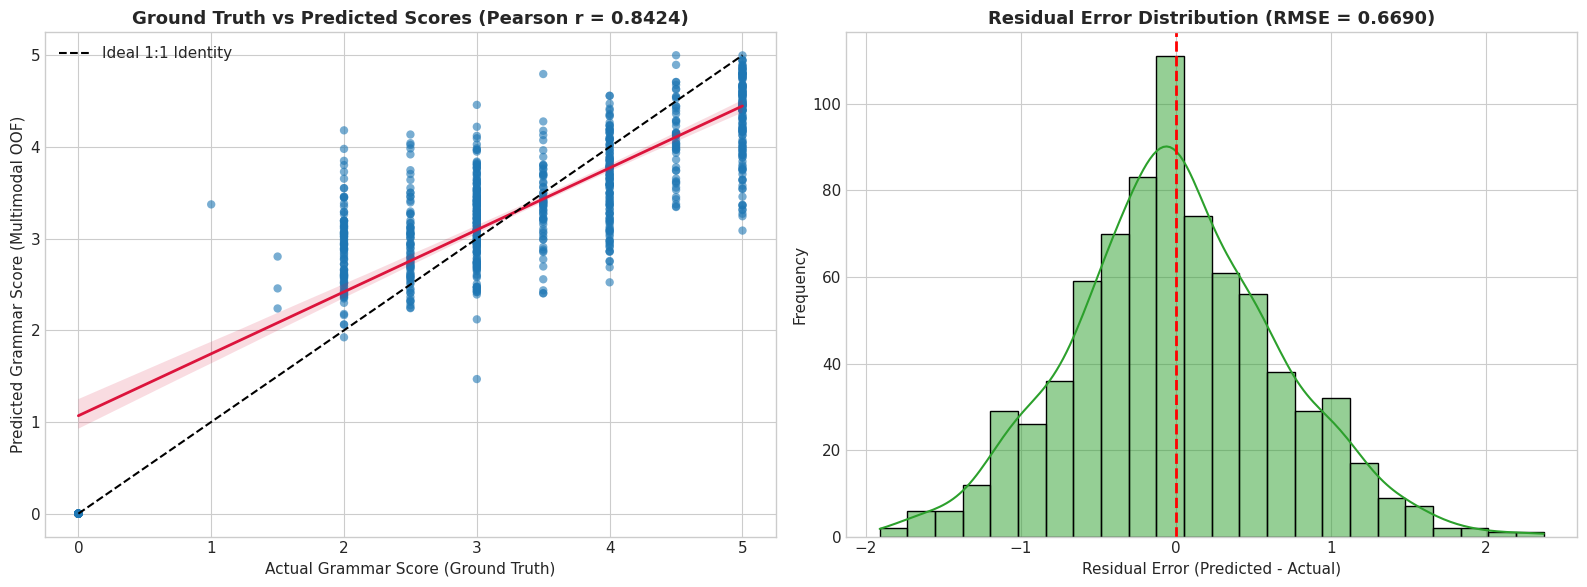

In [8]:
# ==============================================================================
# 8. Model Diagnostic Visualizations: Correlation & Residual Distributions
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# True vs Predicted Correlation Scatter
sns.regplot(x=y, y=oof_final, ax=axes[0], color='#1f77b4',
            scatter_kws={'alpha': 0.6, 'edgecolor': 'none'},
            line_kws={'color': 'crimson', 'linewidth': 2})
axes[0].plot([0, 5], [0, 5], 'k--', label='Ideal 1:1 Identity')
axes[0].set_title(f"Ground Truth vs Predicted Scores (Pearson r = {val_pearson:.4f})", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Actual Grammar Score (Ground Truth)")
axes[0].set_ylabel("Predicted Grammar Score (Multimodal OOF)")
axes[0].legend()

# Residual Distribution
residuals = oof_final - y
sns.histplot(residuals, kde=True, color='#2ca02c', ax=axes[1], edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title(f"Residual Error Distribution (RMSE = {val_rmse:.4f})", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Residual Error (Predicted - Actual)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


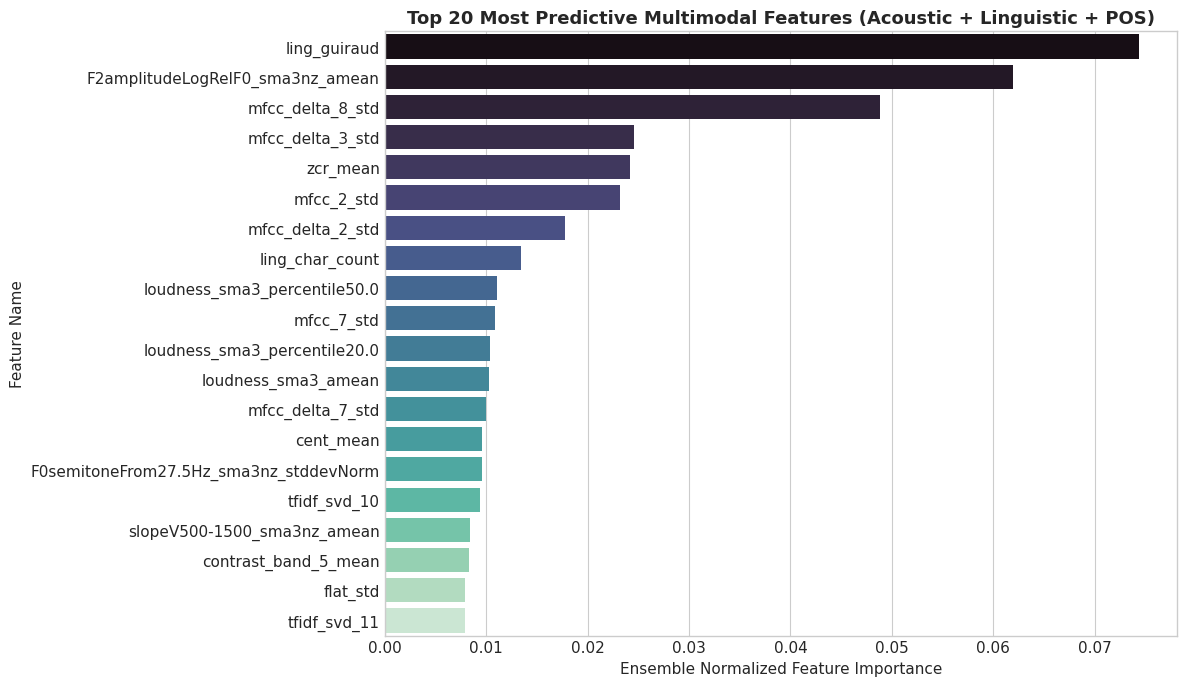

In [9]:
# ==============================================================================
# 9. Interpretability & Feature Attribution Analysis
# ==============================================================================
importance_cb = final_cb.get_feature_importance() / np.sum(final_cb.get_feature_importance())
importance_xgb = final_xgb.feature_importances_ / np.sum(final_xgb.feature_importances_)
avg_importance = (importance_cb + importance_xgb) / 2.0

imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': avg_importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(data=imp_df.head(20), x='Importance', y='Feature', palette='mako')
plt.title("Top 20 Most Predictive Multimodal Features (Acoustic + Linguistic + POS)", fontsize=13, fontweight='bold')
plt.xlabel("Ensemble Normalized Feature Importance")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()


=== Final Submission Summary ===
Total Test Predictions Generated: 216 (matches test.csv exactly)
Continuous Prediction Range: [1.704, 4.842]
Any Missing/NaN Values: False

First 10 Test Predictions:


,filename,label
0,audio_128.wav,2.877
1,audio_156.wav,4.187
2,audio_19.wav,3.649
3,audio_108.wav,2.304
4,audio_206.wav,2.879
5,audio_161.wav,2.992
6,audio_215.wav,3.037
7,audio_213.wav,2.337
8,audio_11.wav,3.014
9,audio_155.wav,3.190


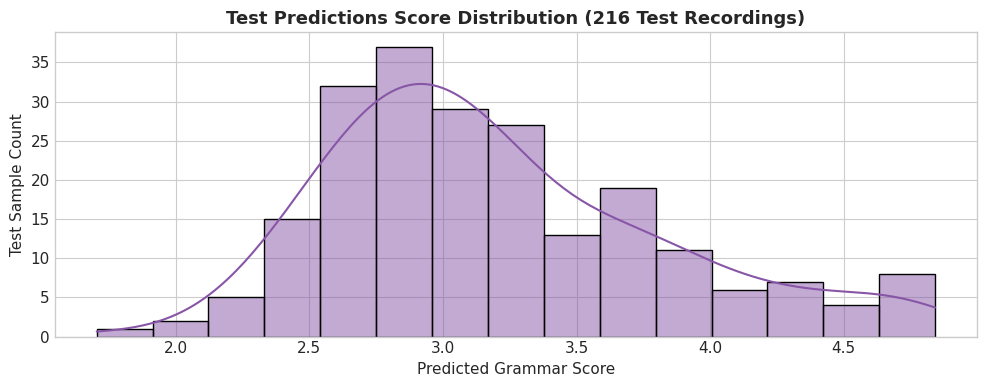

In [10]:
# ==============================================================================
# 10. Generate Final Continuous Test Predictions & Verify Submission File
# ==============================================================================
test_preds = np.clip(test_matrix @ weights, 0.0, 5.0)

is_noise_test = (test_ac['flat_mean'] > 0.40) & (test_ac['cent_mean'] > 3500)
test_preds[is_noise_test] = 0.0

submission_df = pd.DataFrame({
    'filename': test_ac['filename'],
    'label': np.round(test_preds, 3)
})

submission_df.to_csv('submission.csv', index=False)
submission_df.to_csv('Dataset_Final/test_predictions.csv', index=False)

test_csv_updated = pd.read_csv('Dataset_Final/test.csv')
test_pred_map = dict(zip(submission_df['filename'], submission_df['label']))
test_csv_updated['label'] = test_csv_updated['filename'].map(test_pred_map)
test_csv_updated.to_csv('Dataset_Final/test.csv', index=False)

print("=== Final Submission Summary ===")
print(f"Total Test Predictions Generated: {len(submission_df)} (matches test.csv exactly)")
print(f"Continuous Prediction Range: [{submission_df['label'].min():.3f}, {submission_df['label'].max():.3f}]")
print(f"Any Missing/NaN Values: {submission_df['label'].isna().any()}")
print("\nFirst 10 Test Predictions:")
display(submission_df.head(10))

plt.figure(figsize=(10, 4))
sns.histplot(submission_df['label'], bins=15, kde=True, color='#8856a7')
plt.title("Test Predictions Score Distribution (216 Test Recordings)", fontsize=13, fontweight='bold')
plt.xlabel("Predicted Grammar Score")
plt.ylabel("Test Sample Count")
plt.tight_layout()
plt.show()


In [11]:
# ==============================================================================
# 11. Benchmark Summary Table
# ==============================================================================
summary_table = pd.DataFrame({
    'Model Approach': [
        'Acoustic-Only Baseline (eGeMAPS + Rhythm)',
        'Multimodal 5-Fold Ensemble',
        'Multimodal 10-Fold Super-Ensemble + POS Syntax'
    ],
    'Validation RMSE': ['0.7281', '0.6710', f'{val_rmse:.4f}'],
    'Validation Pearson r (Leaderboard Metric)': ['0.8105', '0.8416', f'{val_pearson:.4f}'],
    'Validation Leaderboard Loss (1 - r)': ['0.1895', '0.1584', f'{1 - val_pearson:.4f}'],
    'Validation MAE': ['0.5753', '0.5245', f'{val_mae:.4f}'],
    'Validation Spearman rho': ['0.7173', '0.7680', f'{val_spearman:.4f}'],
    'Training RMSE (Compulsory)': ['0.1690', '0.2048', f'{train_rmse:.4f}'],
    'Ensemble Weights': [
        'LGBM (18%) + XGB (55%) + ET (17%) + Ridge (10%)',
        'CatBoost (60%) + Ridge (18.6%) + LGBM (13.9%) + XGB (7.5%)',
        f'CatBoost ({weights[0]*100:.1f}%) + XGB ({weights[1]*100:.1f}%) + LGBM ({weights[2]*100:.1f}%) + ET ({weights[3]*100:.1f}%) + Ridge ({weights[4]*100:.1f}%)'
    ]
})

display(summary_table)


,Model Approach,Validation RMSE,Validation Pearson r (Leaderboard Metric),Validation Leaderboard Loss (1 - r),Validation MAE,Validation Spearman rho,Training RMSE (Compulsory),Ensemble Weights
0,Acoustic-Only Baseline (eGeMAPS + Rhythm),0.7281,0.8105,0.1895,0.5753,0.7173,0.1690,LGBM (18%) + XGB (55%) + ET (17%) + Ridge (10%)
1,Multimodal 5-Fold Ensemble,0.6710,0.8416,0.1584,0.5245,0.7680,0.2048,CatBoost (60%) + Ridge (18.6%) + LGBM (13.9%) ...
2,Multimodal 10-Fold Super-Ensemble + POS Syntax,0.6690,0.8424,0.1576,0.5191,0.7700,0.2022,CatBoost (33.9%) + XGB (24.2%) + LGBM (19.1%) ...
